<a href="https://colab.research.google.com/github/rufarozhou/HASTS211-Time-Series-Projects/blob/main/Rufaro_D_Zhou_R2420854_HASTS211_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name**: Rufaro D Zhou

**Reg Number**: R2420854

**Course:** HASTS 211 – Time Series and Econometrics
  
**Topics:** Multicollinearity, Skewness, Sensitivity to Outliers, Overfitting


## Setup

In [ ]:
!pip install yfinance --quiet
print("✅ yfinance installed successfully.")


✅ yfinance installed successfully.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, jarque_bera
from numpy.linalg import lstsq

# Global plot style
plt.rcParams.update({
    "figure.dpi":     120,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
})
sns.set_palette("muted")
print("✅ All libraries imported.")


✅ All libraries imported.


## Downloading AAPL Data from Yahoo Finance

In [ ]:
import yfinance as yf

ticker = "AAPL"
START  = "2018-01-01"
END    = "2025-12-31"

raw = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)

if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

df = raw[["Open", "High", "Low", "Close", "Volume"]].copy()
df.index = pd.to_datetime(df.index)
df.index.name = "Date"

print(f"✅ Downloaded {len(df):,} trading days for {ticker}")
print(f"   Date range : {df.index[0].date()} → {df.index[-1].date()}")
print(f"   Columns    : {list(df.columns)}")
df.tail(3)


✅ Downloaded 2,010 trading days for AAPL
   Date range : 2018-01-02 → 2025-12-30
   Columns    : ['Open', 'High', 'Low', 'Close', 'Volume']


Price,Open,High,Low,Close,Volume
Date,,,,,
2025-12-26,273.903708,275.112569,272.604905,273.144409,21521800
2025-12-29,272.435082,274.103504,272.095404,273.504089,23715200
2025-12-30,272.554970,273.823772,272.025467,272.824707,22139600


In [ ]:
df["Return"]     = df["Close"].pct_change()
df["LogReturn"]  = np.log(df["Close"] / df["Close"].shift(1))
df["MA5"]        = df["Close"].rolling(5).mean()
df["MA20"]       = df["Close"].rolling(20).mean()
df["MA60"]       = df["Close"].rolling(60).mean()
df["Volatility"] = df["LogReturn"].rolling(21).std() * np.sqrt(252)
df["Range"]      = df["High"] - df["Low"]
df["MOM"]        = df["Close"] - df["Close"].shift(20)
df = df.dropna().copy()

print(f"Feature-enriched shape : {df.shape}")
df[["Close", "Return", "LogReturn", "Volatility"]].describe().round(6)


Feature-enriched shape : (1951, 13)


Price,Close,Return,LogReturn,Volatility
count,1951.000000,1951.000000,1951.000000,1951.000000
mean,138.191892,0.001179,0.000990,0.279682
std,65.595025,0.019465,0.019445,0.134589
min,33.768078,-0.128647,-0.137708,0.095847
25%,70.781246,-0.007797,-0.007827,0.192850
50%,144.551956,0.001288,0.001287,0.249036
75%,184.534019,0.011174,0.011112,0.323689
max,285.922455,0.153288,0.142617,1.068831


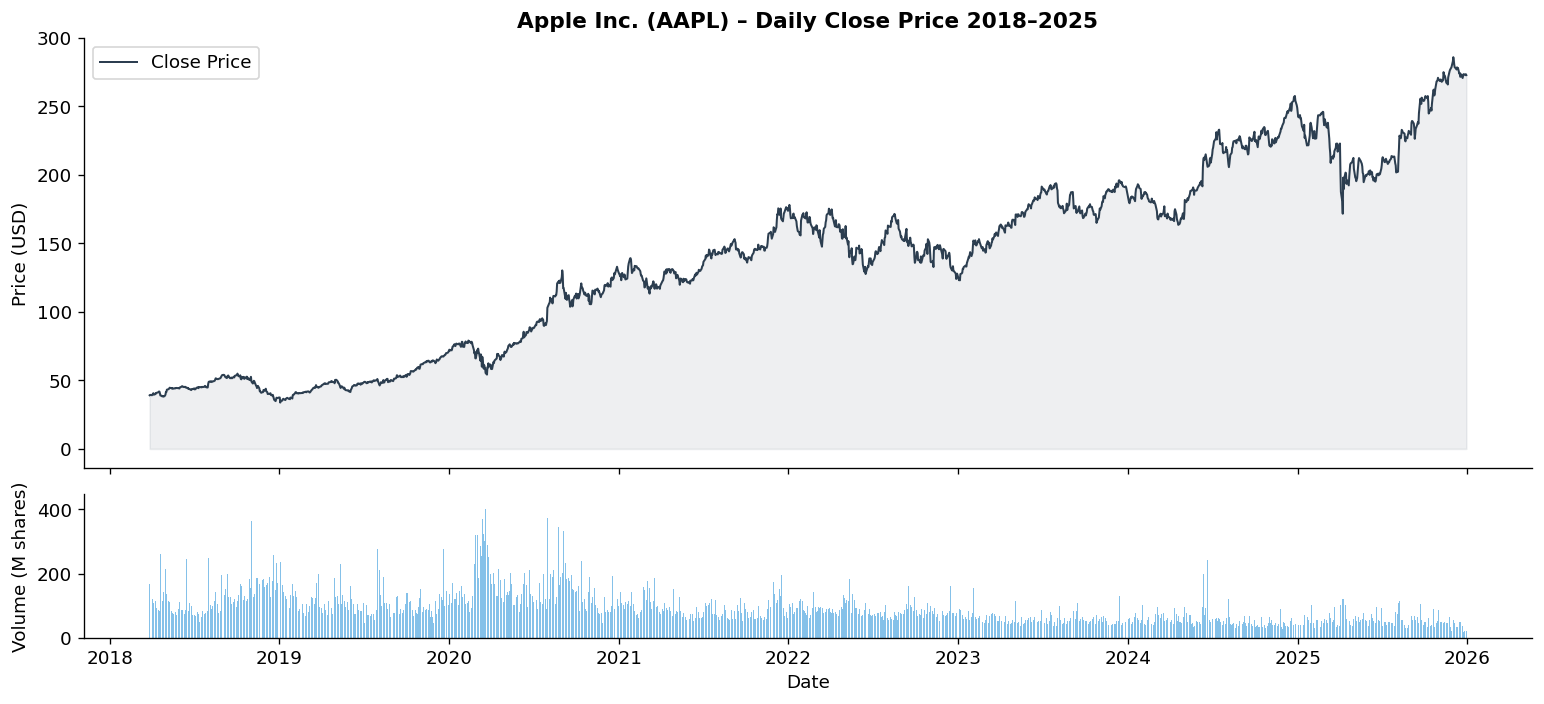

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(df.index, df["Close"], color="#2c3e50", lw=1.2, label="Close Price")
axes[0].fill_between(df.index, df["Close"], alpha=0.08, color="#2c3e50")
axes[0].set_ylabel("Price (USD)")
axes[0].set_title("Apple Inc. (AAPL) – Daily Close Price 2018–2025",
                   fontsize=13, fontweight="bold")
axes[0].legend()

axes[1].bar(df.index, df["Volume"] / 1e6, width=1, color="#3498db", alpha=0.6)
axes[1].set_ylabel("Volume (M shares)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()


## 1. Multicollinearity

### Definition
Multicollinearity means the presence of a linear relationship among the explanatory variables, of the form **a`X**=c where **a** and c are constant vector and constant scalar respectively.

If **X** is the design matrix, multicollinearity implies a near-singular **X′X**, inflating coefficient variances:

$$\text{Var}(\hat{\beta}) = \sigma^2 (X'X)^{-1}$$

The standard diagnostic is the **Variance Inflation Factor (VIF)**:

$$\text{VIF}_j = \dfrac{1}{1 - R_j^2}$$

where $R_j^2$ is the $R^2$ from regressing predictor $j$ on all other predictors.  
A VIF > **10** is considered severe; VIF > **5** is moderate.

---

### Description
Multicollinearity happens when predictors move together so closely that the model cannot tell which one is driving the outcome. The overall model fit (R²) may look excellent, but the individual coefficient estimates become unreliable, their standard errors balloon, and inference breaks down.


In [ ]:
df = raw[["Open", "High", "Low", "Close", "Volume"]].copy()
df.index = pd.to_datetime(df.index)
df.index.name = "Date"

df["Return"]     = df["Close"].pct_change()
df["LogReturn"]  = np.log(df["Close"] / df["Close"].shift(1))
df["MA5"]        = df["Close"].rolling(5).mean()
df["MA20"]       = df["Close"].rolling(20).mean()
df["MA60"]       = df["Close"].rolling(60).mean()
df["Volatility"] = df["LogReturn"].rolling(21).std() * np.sqrt(252)
df["Range"]      = df["High"] - df["Low"]
df["MOM"]        = df["Close"] - df["Close"].shift(20)
df = df.dropna().copy()

# ── CELL 6: Compute VIF for each technical feature (Challenge 1) ─────────
features = ["MA5", "MA20", "MA60", "MOM", "Volatility", "Range", "Volume"]

# Standardise so that VIF is scale-independent
X = df[features].copy()
X = (X - X.mean()) / X.std()

vif_records = []
for col in features:
    others = [c for c in features if c != col]
    Xo = np.column_stack([np.ones(len(X)), X[others].values])
    yj = X[col].values
    coef, *_ = lstsq(Xo, yj, rcond=None)
    y_hat     = Xo @ coef
    ss_res    = np.sum((yj - y_hat) ** 2)
    ss_tot    = np.sum((yj - yj.mean()) ** 2)
    r2        = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    vif       = round(1 / (1 - r2), 2) if r2 < 0.9999 else 99999
    flag      = "⚠️  HIGH" if vif > 10 else "✅  OK"
    vif_records.append({"Feature": col, "VIF": vif, "Status": flag})

vif_df = pd.DataFrame(vif_records).set_index("Feature")
print("=" * 40)
print(f"{'Feature':<12} {'VIF':>10}  Status")
print("=" * 40)
for feat, row in vif_df.iterrows():
    print(f"{feat:<12} {row['VIF']:>10,.2f}  {row['Status']}")
print("=" * 40)
print("\nRule of thumb: VIF > 10 → severe multicollinearity")

Feature             VIF  Status
MA5              634.27  ⚠️  HIGH
MA20             674.00  ⚠️  HIGH
MA60             142.88  ⚠️  HIGH
MOM                4.07  ✅  OK
Volatility         1.63  ✅  OK
Range              2.16  ✅  OK
Volume             2.34  ✅  OK

Rule of thumb: VIF > 10 → severe multicollinearity


### Diagram – Correlation Heat-map and VIF Bar Chart

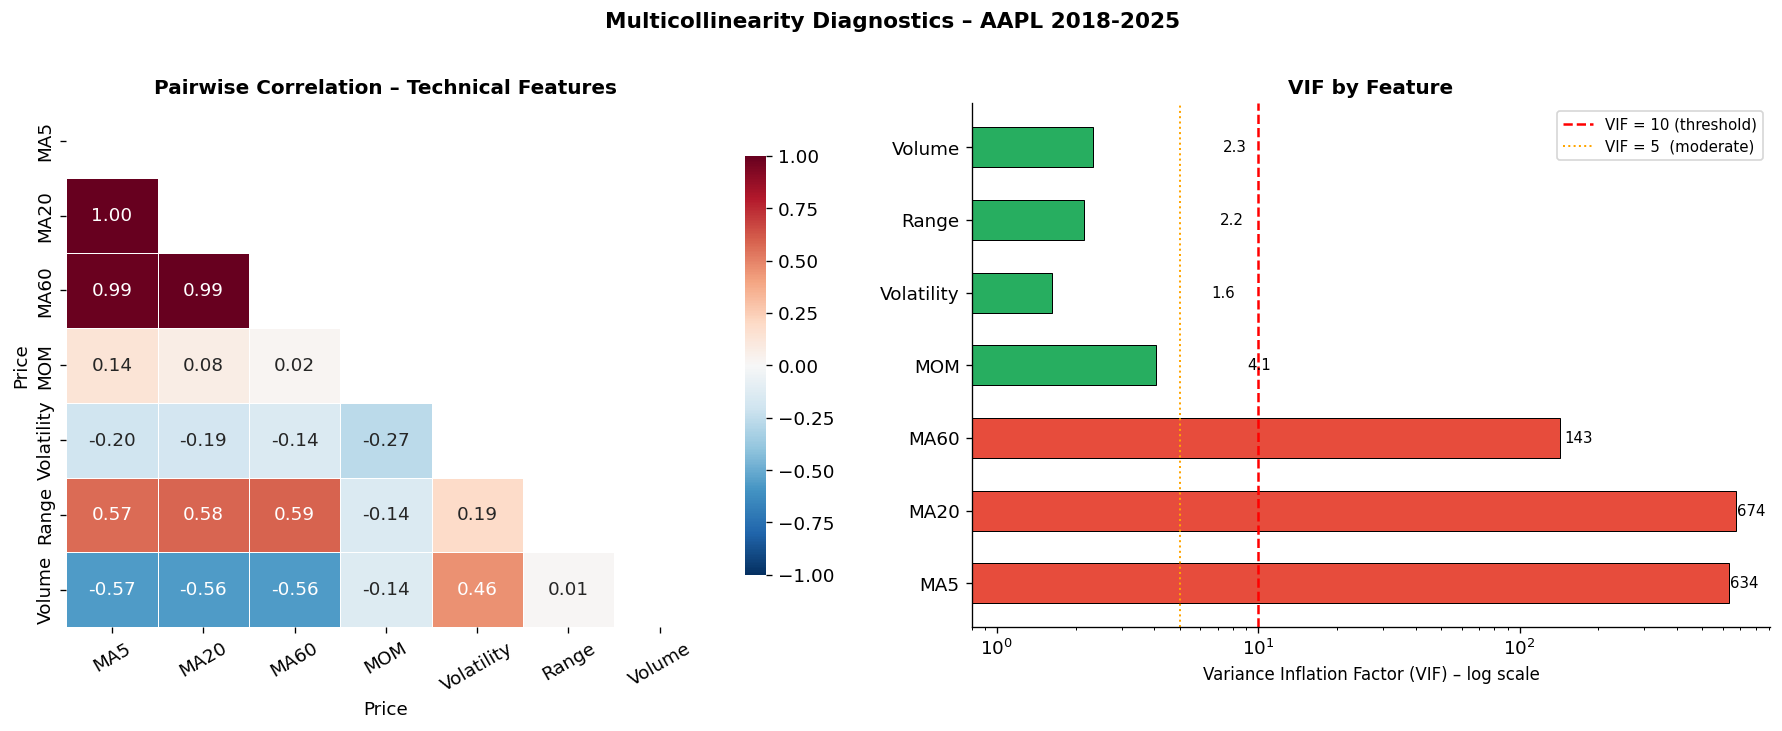

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- (a) Correlation matrix ---
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle only
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=axes[0],
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title("Pairwise Correlation – Technical Features", fontsize=12, fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)

# --- (b) VIF bar chart ---
vif_vals  = vif_df["VIF"].values
bar_cols  = ["#e74c3c" if v > 10 else "#27ae60" for v in vif_vals]
bars = axes[1].barh(vif_df.index, vif_vals, color=bar_cols,
                    edgecolor="black", linewidth=0.6, height=0.55)
axes[1].axvline(10, color="red", linestyle="--", linewidth=1.5,
                label="VIF = 10 (threshold)")
axes[1].axvline(5,  color="orange", linestyle=":",  linewidth=1.2,
                label="VIF = 5  (moderate)")

# Label each bar
for bar, v in zip(bars, vif_vals):
    label = f"{v:,.0f}" if v > 100 else f"{v:.1f}"
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 label, va="center", fontsize=9)

axes[1].set_xscale("log")
axes[1].set_xlabel("Variance Inflation Factor (VIF) – log scale", fontsize=10)
axes[1].set_title("VIF by Feature", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].set_xlim(left=0.8)

plt.suptitle("Multicollinearity Diagnostics – AAPL 2018-2025",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### Diagnosis
- **VIF > 10**: Severe multicollinearity (model coefficients are unstable).
- **VIF > 5**: Moderate — worth investigating.
- **Near-1 pairwise correlations** (|r| > 0.90) visible in the heat-map.
- **Condition number** of the design matrix X′X > 30 signals near-singularity.
- A telltale sign in practice: coefficients that flip sign or become implausibly large when a feature is added or removed.

### Damage
Multicollinearity does not bias coefficient estimates but severely inflates their variance, meaning that:
- Standard errors are large - t-statistics are small - genuinely important predictors appear statistically insignificant.
- Hedge ratios derived from unstable coefficients fluctuate wildly day-to-day, causing over-hedging or under-hedging.
- A model re-estimated on slightly different data may produce completely different coefficients, destroying consistency across the desk.

### Directions
| Direction | How it Works |
|--------|-------------|
| **Remove redundant features** | Drop one from each highly correlated pair. |
| **Ridge Regression** |Shrinks unstable coefficients toward zero without removing them. |
| **Principal Component Regression** | Transforms collinear features into orthogonal components. |
| **Partial Least Squares** | Similar to PCR but maximises covariance with the response. |


## 2. Skewness

### Definition
Skewness measures the asymmetry of a probability distribution around its mean. For a random variable $X$ with mean $\mu$ and standard deviation $\sigma$:

$$\text{Skewness} = \frac{E\left[(X - \mu)^3\right]}{\sigma^3}$$

- **= 0**: Perfectly symmetric (Normal distribution)
- **> 0**: Right-skewed — long right tail (large positive returns more frequent than large losses)
- **< 0**: Left-skewed — long left tail (crashes more common than equivalent rallies; typical for equities)

The **Jarque-Bera test** jointly tests for zero skewness and zero excess kurtosis:

$$JB = \frac{n}{6}\left(S^2 + \frac{(K-3)^2}{4}\right) \sim \chi^2(2) \text{ under normality}$$

---

### Description
Equity log-returns tend to be negatively skewed, large losses occur more frequently and more severely than equivalent gains. If a volatility model assumes normally distributed returns and ignores skewness, it will systematically underprice put options, underestimate Value-at-Risk, and expose the desk to unexpected downside losses.


In [ ]:
# CELL 8: Skewness statistics for AAPL log-returns
ret = df["LogReturn"].dropna()

sample_skew  = skew(ret)
excess_kurt  = kurtosis(ret)           # excess kurtosis (normal = 0)
jb_stat, jb_p = jarque_bera(ret)

print("=" * 50)
print("  AAPL Log-Return Descriptive Statistics")
print("=" * 50)
print(f"  Observations       : {len(ret):>10,}")
print(f"  Mean               : {ret.mean():>14.6f}")
print(f"  Std Dev            : {ret.std():>14.6f}")
print(f"  Skewness           : {sample_skew:>14.4f}")
print(f"  Excess Kurtosis    : {excess_kurt:>14.4f}")
print(f"  Jarque-Bera stat   : {jb_stat:>14.2f}")
print(f"  Jarque-Bera p-val  : {jb_p:>14.4e}")
print("=" * 50)

if abs(sample_skew) > 1.0:
    print(f"\n  ⚠️  SEVERE skewness  |{sample_skew:.2f}| > 1.0")
elif abs(sample_skew) > 0.5:
    print(f"\n  ⚠️  MODERATE skewness |{sample_skew:.2f}| > 0.5")
else:
    print(f"\n  ✅  Skewness is mild: {sample_skew:.2f}")

if jb_p < 0.05:
    print(f"  ⚠️  Normality REJECTED at 5% level (Jarque-Bera p = {jb_p:.2e})")
else:
    print(f"  ✅  Cannot reject normality at 5% level (p = {jb_p:.4f})")


  AAPL Log-Return Descriptive Statistics
  Observations       :      1,951
  Mean               :       0.000990
  Std Dev            :       0.019445
  Skewness           :        -0.0958
  Excess Kurtosis    :         6.2832
  Jarque-Bera stat   :        3212.25
  Jarque-Bera p-val  :     0.0000e+00

  ✅  Skewness is mild: -0.10
  ⚠️  Normality REJECTED at 5% level (Jarque-Bera p = 0.00e+00)


### Diagram – Return Distribution, Q-Q Plot, and Rolling Skewness

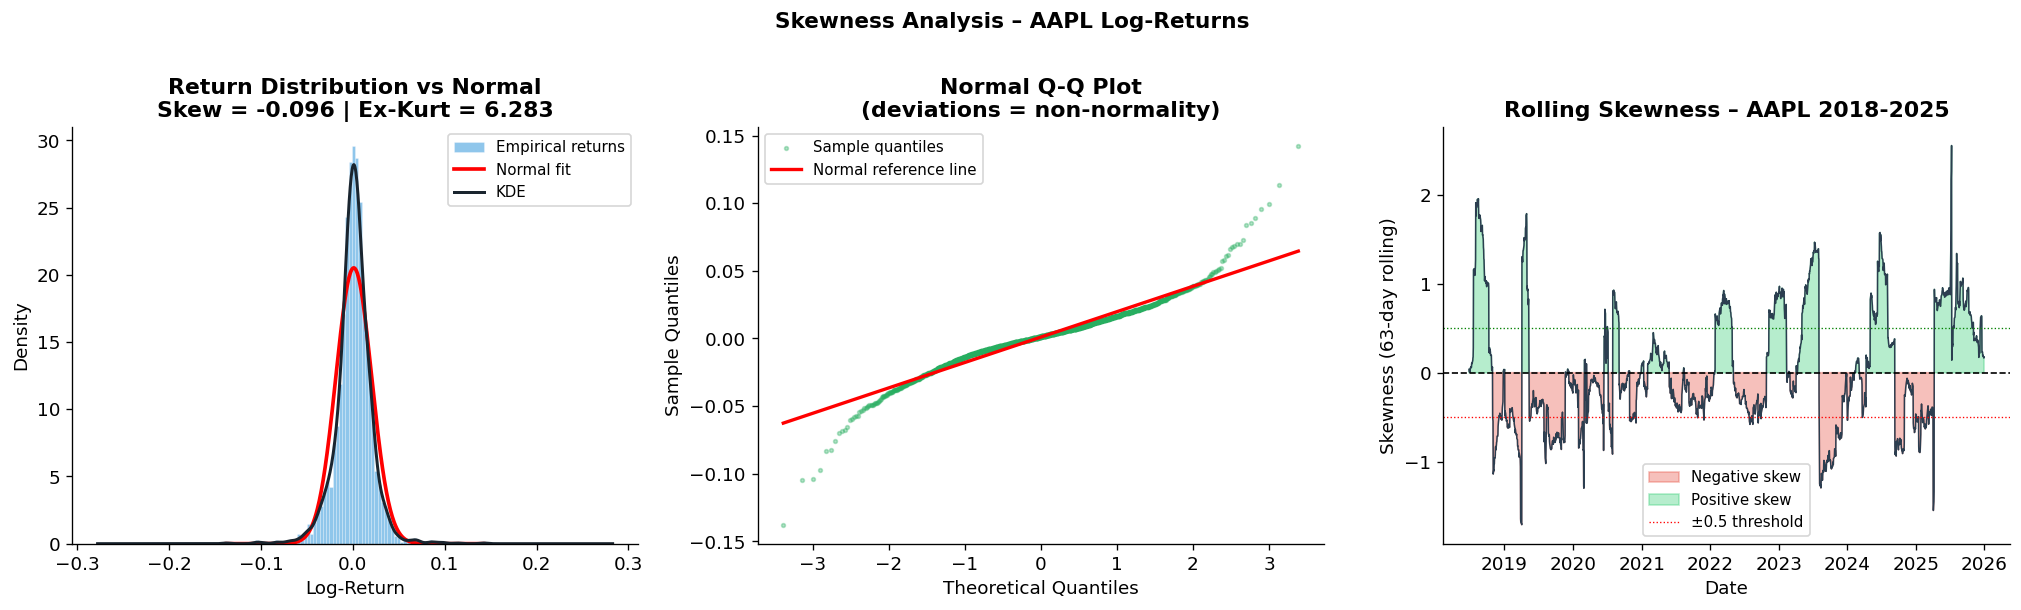

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

mu_r, sd_r = ret.mean(), ret.std()
x_grid = np.linspace(ret.min(), ret.max(), 400)

# --- (a) Histogram + KDE + Normal overlay ---
axes[0].hist(ret, bins=80, density=True, color="#3498db", alpha=0.55,
             edgecolor="white", linewidth=0.3, label="Empirical returns")
axes[0].plot(x_grid, stats.norm.pdf(x_grid, mu_r, sd_r),
             "r-", lw=2.2, label="Normal fit")
ret.plot.kde(ax=axes[0], color="#1a252f", lw=1.8, label="KDE")
axes[0].set_xlabel("Log-Return")
axes[0].set_ylabel("Density")
axes[0].set_title("Return Distribution vs Normal\n"
                  f"Skew = {sample_skew:.3f} | Ex-Kurt = {excess_kurt:.3f}",
                  fontweight="bold")
axes[0].legend(fontsize=9)

# --- (b) Q-Q plot ---
(osm, osr), (slope, intercept, _) = stats.probplot(ret, dist="norm")
axes[1].scatter(osm, osr, s=5, alpha=0.35, color="#27ae60", label="Sample quantiles")
ref_line = slope * np.array([osm[0], osm[-1]]) + intercept
axes[1].plot([osm[0], osm[-1]], ref_line, "r-", lw=2, label="Normal reference line")
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Sample Quantiles")
axes[1].set_title("Normal Q-Q Plot\n(deviations = non-normality)", fontweight="bold")
axes[1].legend(fontsize=9)

# --- (c) Rolling 63-day skewness ---
roll_sk = df["LogReturn"].rolling(63).apply(skew, raw=True)
axes[2].fill_between(roll_sk.index, roll_sk,
                     where=roll_sk < 0, color="#e74c3c", alpha=0.35, label="Negative skew")
axes[2].fill_between(roll_sk.index, roll_sk,
                     where=roll_sk >= 0, color="#2ecc71", alpha=0.35, label="Positive skew")
axes[2].plot(roll_sk.index, roll_sk, color="#2c3e50", lw=0.9)
axes[2].axhline(0, color="black", lw=1, linestyle="--")
axes[2].axhline(-0.5, color="red",   lw=0.8, linestyle=":", label="±0.5 threshold")
axes[2].axhline( 0.5, color="green", lw=0.8, linestyle=":")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Skewness (63-day rolling)")
axes[2].set_title("Rolling Skewness – AAPL 2018-2025", fontweight="bold")
axes[2].legend(fontsize=9)

plt.suptitle("Skewness Analysis – AAPL Log-Returns",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### Diagnosis
- **Sample skewness**: |S| > 0.5 is moderate; |S| > 1.0 is severe.
- **Jarque-Bera test** (p < 0.05): rejects joint hypothesis that skewness = 0 and excess kurtosis = 0.
- **Q-Q plot**: systematic curvature (S-shape) away from the 45° reference line, especially in the tails.
- **Rolling skewness**: persistent negative values indicate a structural, time-varying left-tail risk — common before and during market downturns.

### Damage
- **Mis-priced options**: Black-Scholes assumes log-normal returns. Negative skewness means put options (downside protection) are underpriced under naive models.
- **Invalid OLS inference**: t-tests and confidence intervals for regression coefficients break down when residuals are skewed, producing false signals about which factors matter.

### Directions
| Direction | How it Works |
|--------|-------------|
| **Student-t GARCH** | Models heavy tails and asymmetry directly via the degrees-of-freedom parameter. |
| **Cornish-Fisher VaR expansion** | Adjusts the Normal quantile for observed skewness and excess kurtosis without assuming a parametric distribution. |
| **Skew-Normal or NIG distribution** | Explicitly parametrises skewness in option pricing models. |


## 3. Sensitivity to Outliers

### Definition
An outlier is an observation that lies far from the bulk of the data. A robust detection criterion is the **Modified Z-score** (Iglewicz & Hoaglin, 1993):

$$M_i = \frac{0.6745\;(x_i - \tilde{x})}{\text{MAD}}$$

where $\tilde{x}$ is the sample **median** and $\text{MAD} = \text{median}(|x_i - \tilde{x}|)$ is the Median Absolute Deviation.  
Observations with $|M_i| > 3.5$ are flagged as outliers (robust to the outliers themselves).

OLS minimises squared residuals, so one large residual dominates:

$$\hat{\beta}_{\text{OLS}} = \arg\min_{\beta}\;\sum_{i=1}^{n}(y_i - x_i'\beta)^2$$

One extreme observation can shift $\hat{\beta}$ more than hundreds of normal observations combined.

---

### Description
Outliers in financial returns, caused by earnings surprises or flash crashes, can seriously distort parameter estimates and cause risk models to overestimate or underestimate tail risk because a quant's job is to price and hedge derivatives, even if one mislabeled market crash can produce incorrect hedge ratios across an entire book.


### Demonstration

In [ ]:
ret = df["LogReturn"].copy()

median_r = ret.median()
mad      = (ret - median_r).abs().median()
mod_z    = 0.6745 * (ret - median_r) / mad

outlier_mask = mod_z.abs() > 3.5
normal_mask  = ~outlier_mask

n_total    = len(ret)
n_outliers = outlier_mask.sum()

print("=" * 55)
print("  Outlier Detection – Modified Z-Score  (|M| > 3.5)")
print("=" * 55)
print(f"  Total trading days : {n_total:>8,}")
print(f"  Outlier days       : {n_outliers:>8,}  ({100*n_outliers/n_total:.1f}%)")
print("=" * 55)

# Show the 10 most extreme
top10 = mod_z[outlier_mask].abs().nlargest(10)
print("\n  Top 10 Extreme Outlier Days:")
print(f"  {'Date':<14} {'LogReturn':>10} {'|ModZ|':>8}")
print("  " + "-" * 36)
for d in top10.index:
    print(f"  {str(d.date()):<14} {ret[d]:>10.4f} {abs(mod_z[d]):>8.2f}")


  Outlier Detection – Modified Z-Score  (|M| > 3.5)
  Total trading days :    1,951
  Outlier days       :       48  (2.5%)

  Top 10 Extreme Outlier Days:
  Date            LogReturn   |ModZ|
  ------------------------------------
  2025-04-09         0.1426    10.09
  2020-03-16        -0.1377     9.93
  2020-03-13         0.1132     7.99
  2019-01-03        -0.1049     7.58
  2020-03-12        -0.1040     7.52
  2025-04-03        -0.0970     7.02
  2020-07-31         0.0996     7.02
  2020-03-24         0.0956     6.74
  2020-03-02         0.0890     6.27
  2020-09-03        -0.0834     6.05


### Diagram – Outlier Time-Series and OLS Sensitivity

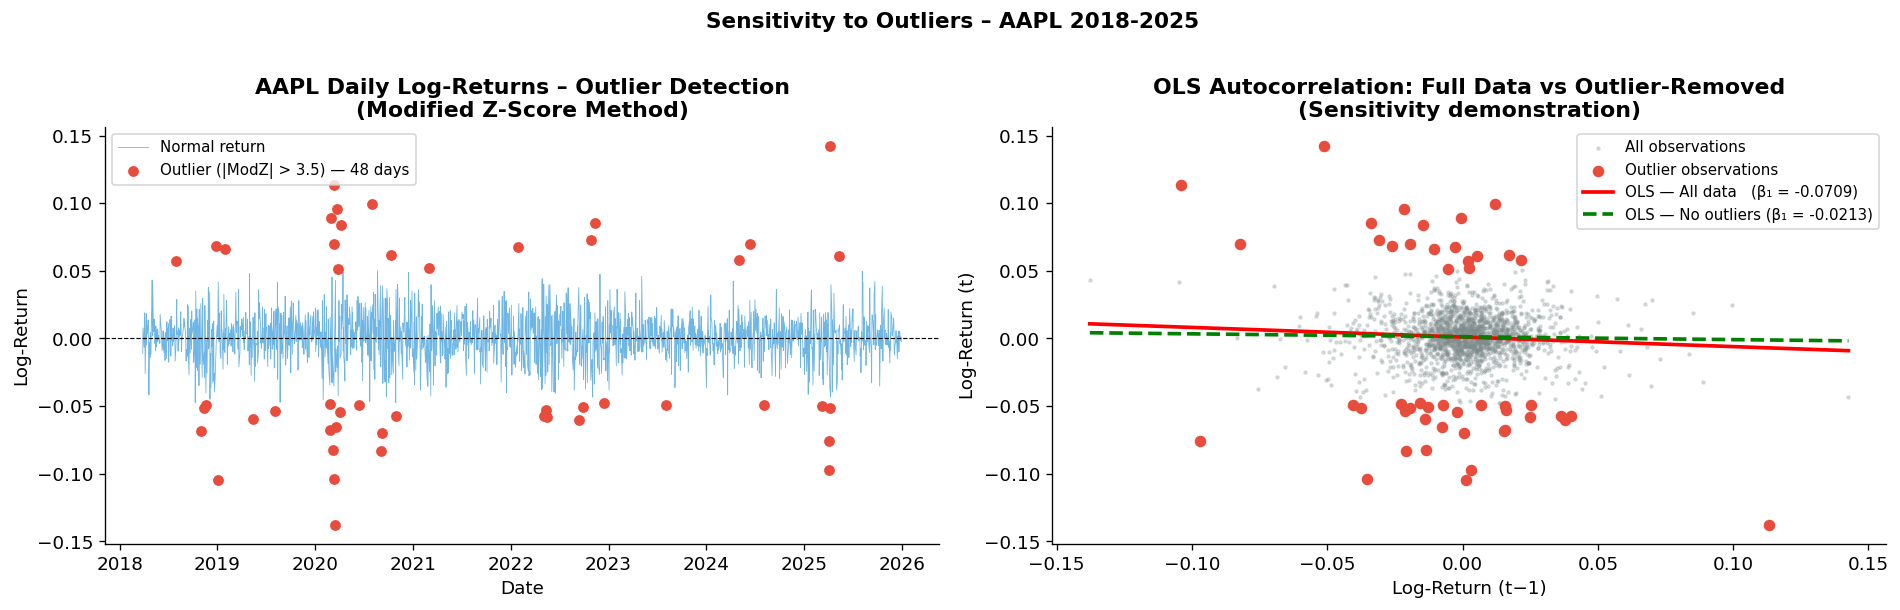


Slope shift due to outliers: 0.049520   (232.1% change)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- (a) Return time-series with outlier flags ---
axes[0].plot(ret.index[normal_mask], ret[normal_mask],
             lw=0.5, color="#3498db", alpha=0.7, label="Normal return")
axes[0].scatter(ret.index[outlier_mask], ret[outlier_mask],
                color="#e74c3c", s=30, zorder=5,
                label=f"Outlier (|ModZ| > 3.5) — {n_outliers} days")
axes[0].axhline(0, color="black", lw=0.7, linestyle="--")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Log-Return")
axes[0].set_title("AAPL Daily Log-Returns – Outlier Detection\n"
                  "(Modified Z-Score Method)", fontweight="bold")
axes[0].legend(fontsize=9)

# --- (b) OLS autocorrelation fit: full data vs outlier-removed ---
# Regress Return(t) on Return(t-1)
y_full = ret.values[1:]
x_full = ret.values[:-1]

# Outlier mask aligned to lagged series
out_shifted = outlier_mask.values[1:]  # align with y_full

y_clean = y_full[~out_shifted]
x_clean = x_full[~out_shifted]

def ols_slope_intercept(x, y):
    b1 = np.cov(x, y)[0, 1] / np.var(x)
    b0 = y.mean() - b1 * x.mean()
    return b0, b1

b0_full,  b1_full  = ols_slope_intercept(x_full,  y_full)
b0_clean, b1_clean = ols_slope_intercept(x_clean, y_clean)

x_line = np.linspace(x_full.min(), x_full.max(), 300)

axes[1].scatter(x_full, y_full, s=3, alpha=0.25, color="#7f8c8d", label="All observations")
axes[1].scatter(x_full[out_shifted], y_full[out_shifted],
                color="#e74c3c", s=35, zorder=5, label="Outlier observations")
axes[1].plot(x_line, b0_full  + b1_full  * x_line, "r-",  lw=2.2,
             label=f"OLS — All data   (β₁ = {b1_full:.4f})")
axes[1].plot(x_line, b0_clean + b1_clean * x_line, "g--", lw=2.2,
             label=f"OLS — No outliers (β₁ = {b1_clean:.4f})")

axes[1].set_xlabel("Log-Return (t−1)")
axes[1].set_ylabel("Log-Return (t)")
axes[1].set_title("OLS Autocorrelation: Full Data vs Outlier-Removed\n"
                  "(Sensitivity demonstration)", fontweight="bold")
axes[1].legend(fontsize=9)

plt.suptitle("Sensitivity to Outliers – AAPL 2018-2025",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Numerical summary
print(f"\nSlope shift due to outliers: {abs(b1_full - b1_clean):.6f}",
      f"  ({100*abs(b1_full-b1_clean)/abs(b1_clean):.1f}% change)")


### Diagnosis
- **Modified Z-score** |M| > 3.5: Robust to the outliers themselves (unlike standard Z-scores).
- **Cook's Distance** in a regression: Observations with Cook's D > 4/n are highly influential.
- **Scatter-plots and box-plots**: Quick visual first pass.

### Damage
- A single extreme return day can shift OLS coefficients more than months of normal data, making the estimated model useless for the current market.
- Historical volatility estimates are artificially inflated after a crash event, causing option premiums to be overpriced for weeks afterward.
- Automated trading strategies can generate **false signals** triggered by the outlier rather than genuine market dynamics.

### Directions
| Remedy | How it Works |
|--------|-------------|
| **Huber Regression (M-estimation)** | Uses a loss function that is quadratic for small residuals but linear for large ones. |
| **Least Absolute Deviations** | Minimises all the loss in the deviations |residuals| instead of residuals² — inherently robust to extreme observations. |
| **GARCH models** | Explicitly model time-varying volatility; a large shock updates σ² but does not distort the mean or level estimates. |
| **Student-t / Stable distribution** | Heavier tails mean extreme observations are more expected. |


## 4. Overfitting

### Definition
Overfitting occurs when a model learns the noise specific to the training sample in addition to the true signal, resulting in excellent in-sample fit but poor out-of-sample generalisation.

The expected out-of-sample Mean Squared Error (MSE) decomposes as:

$$E\left[(y - \hat{f}(x))^2\right] = \underbrace{\text{Bias}^2[\hat{f}]}_{\text{under-fit}} + \underbrace{\text{Var}[\hat{f}]}_{\text{over-fit}} + \sigma^2_{\varepsilon}$$

A high-complexity model drives Bias towards 0 but inflates Variance, raising total test-set error.  
The optimal model minimises the sum of all three terms.

---

### Description
In financial time-series, market data is scarce relative to the number of potential predictors, making overfitting an ever-present danger. A model that fits every past price wiggle perfectly will fail on live data because those wiggles were random noise, not repeatable patterns.


In [ ]:
# CELL 12: Overfitting demo – polynomial regression on AAPL price
# Strategy: fit polynomial of degree 1, 3, 9 on 80% of data,
# evaluate RMSE on the remaining 20%.  Higher degree = more complex = more overfit.

price = df["Close"].values
t_idx = np.arange(len(price))

split      = int(len(price) * 0.80)
t_train, p_train = t_idx[:split], price[:split]
t_test,  p_test  = t_idx[split:], price[split:]

# Normalise t to [0, 1] for numerical stability of high-degree polynomials
def normalise(t, t_ref_min, t_ref_max):
    return (t - t_ref_min) / (t_ref_max - t_ref_min)

t_n_train = normalise(t_train, t_train.min(), t_train.max())
t_n_test  = normalise(t_test,  t_train.min(), t_train.max())

results = {}
print("=" * 60)
print(f"  {'Degree':<10} {'In-sample RMSE':>18} {'Out-of-sample RMSE':>20}")
print("=" * 60)

for deg in [1, 2, 3, 5, 9]:
    coef         = np.polyfit(t_n_train, p_train, deg)
    hat_train    = np.polyval(coef, t_n_train)
    hat_test     = np.polyval(coef, t_n_test)
    rmse_in      = np.sqrt(np.mean((p_train - hat_train) ** 2))
    rmse_out     = np.sqrt(np.mean((p_test  - hat_test)  ** 2))
    results[deg] = {"hat_test": hat_test, "rmse_in": rmse_in, "rmse_out": rmse_out}
    flag = "⚠️  OVERFIT" if rmse_out > 3 * rmse_in else "✅"
    print(f"  {deg:<10} {rmse_in:>18.2f} {rmse_out:>20.2f}  {flag}")

print("=" * 60)
print("\nNote: A good model should have similar in-sample and out-of-sample RMSE.")


  Degree         In-sample RMSE   Out-of-sample RMSE
  1                       15.86                21.87  ✅
  2                       14.94                37.02  ✅
  3                       13.57                91.23  ⚠️  OVERFIT
  5                       11.45                83.77  ⚠️  OVERFIT
  9                        9.04              5057.75  ⚠️  OVERFIT

Note: A good model should have similar in-sample and out-of-sample RMSE.


### Diagram: Bias-Variance Trade-Off and Out-of-Sample Fit

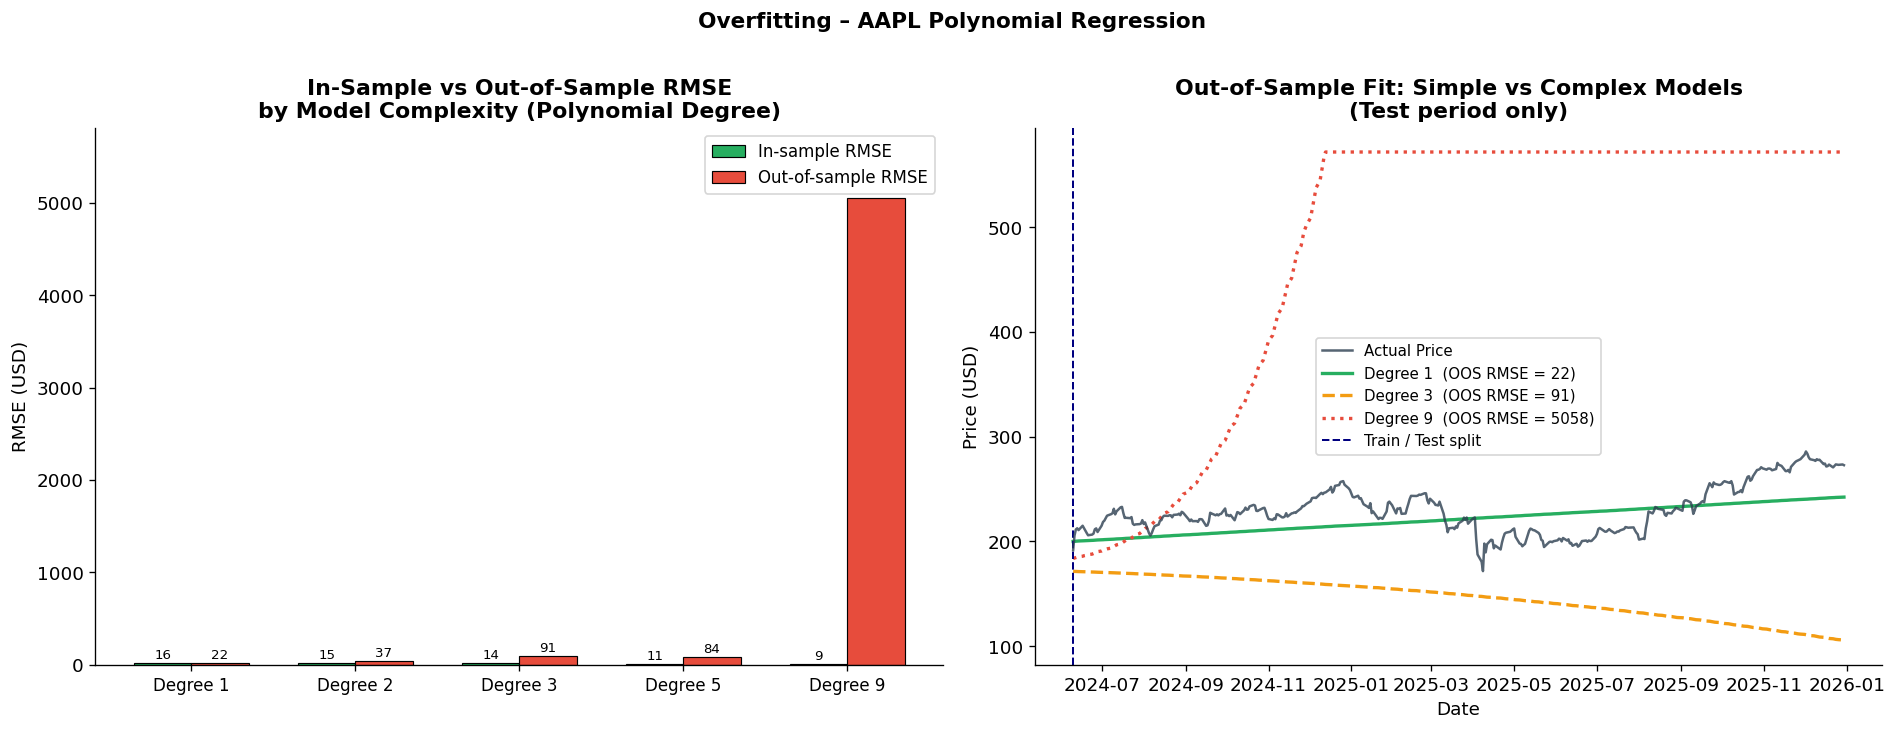

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- (a) In-sample vs Out-of-sample RMSE by model degree ---
degrees  = list(results.keys())
rmse_in  = [results[d]["rmse_in"]  for d in degrees]
rmse_out = [results[d]["rmse_out"] for d in degrees]

x_pos = np.arange(len(degrees))
width = 0.35

bars_in  = axes[0].bar(x_pos - width/2, rmse_in,  width,
                        label="In-sample RMSE",       color="#27ae60", edgecolor="black", lw=0.7)
bars_out = axes[0].bar(x_pos + width/2, rmse_out, width,
                        label="Out-of-sample RMSE",   color="#e74c3c", edgecolor="black", lw=0.7)

# Add value labels on bars
for bar in list(bars_in) + list(bars_out):
    h = bar.get_height()
    if h < 5000:
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 15,
                     f"{h:.0f}", ha="center", va="bottom", fontsize=8)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f"Degree {d}" for d in degrees], fontsize=10)
axes[0].set_ylabel("RMSE (USD)")
axes[0].set_title("In-Sample vs Out-of-Sample RMSE\n"
                   "by Model Complexity (Polynomial Degree)", fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, max(rmse_out) * 1.15)

# --- (b) Out-of-sample predictions for degrees 1, 3, 9 ---
split_date = df.index[split]
colors     = {1: "#27ae60", 3: "#f39c12", 9: "#e74c3c"}
linestyles = {1: "-",       3: "--",      9: ":"}

axes[1].plot(df.index[split:], p_test, color="#2c3e50",
             lw=1.5, alpha=0.8, label="Actual Price", zorder=10)

for deg in [1, 3, 9]:
    hat = results[deg]["hat_test"]
    # Clip extreme polynomial explosion for display purposes
    hat_clipped = np.clip(hat, p_test.min() * 0.5, p_test.max() * 2)
    axes[1].plot(df.index[split:], hat_clipped,
                 color=colors[deg], lw=2, linestyle=linestyles[deg],
                 label=f"Degree {deg}  (OOS RMSE = {results[deg]['rmse_out']:.0f})")

axes[1].axvline(split_date, color="navy", lw=1.2, linestyle="--",
                label="Train / Test split")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Price (USD)")
axes[1].set_title("Out-of-Sample Fit: Simple vs Complex Models\n"
                   "(Test period only)", fontweight="bold")
axes[1].legend(fontsize=9)

plt.suptitle("Overfitting – AAPL Polynomial Regression",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### Diagnosis
- **Train / Test split**: A large gap between in-sample and out-of-sample RMSE is the clearest sign of overfitting.
- **k-fold Cross-Validation**: Repeat evaluation across multiple folds; an overfit model will show high variance in fold-level error.
- **Learning curves**: Plot training and validation error versus sample size. Overfitting shows a large, persistent gap.
- **Walk-forward (rolling) backtest**: Re-fit on rolling windows and evaluate on the subsequent unseen period — the most realistic test for financial models.

### Damage
- **Incorrect option pricing/volatility surfaces**: An overfit volatility surface matches every historical data point but cannot extrapolate correctly to new strikes or maturities.
- **Regulatory risk**: Risk models that overfit underestimate tail risk, leading to insufficient capital buffers.
- **False confidence**: Traders and managers trust the backtest, size positions aggressively, and suffer outsized losses when the model inevitably fails.

### Directions
| Remedy | How it Works |
|--------|-------------|
| **Ridge Regression** | Shrinks all coefficients — reduces model complexity without eliminating predictors. |
| **Lasso Regression** | Sets some coefficients exactly to zero — automatic feature selection reduces overfitting. |
| **Early stopping** | In gradient-boosting or neural networks, stop training when the validation error starts rising. |
| **Dimensionality reduction** | Fewer free parameters - less room to overfit to noise. |


## Summary Table

| # | Challenge | Key Diagnostic Tool | Primary Damage | Best Remedy |
|---|-----------|-------------------|----------------|------------|
| 1 | **Multicollinearity** | VIF > 10; correlation heat-map | Inflated standard errors | Ridge Regression / PCR |
| 2 | **Skewness** | Jarque-Bera test; Q-Q plot | Underestimated Variance | GJR-GARCH / Cornish-Fisher VaR |
| 3 | **Sensitivity to Outliers** | Modified Z-score | Wrong volatility estimates | Huber Regression / Winsorization |
| 4 | **Overfitting** | Train/test RMSE gap | Strategy collapse | Cross-validation |

---
## References

Brooks, C. (2019). *Introductory Econometrics for Finance* (4th ed.). Cambridge University Press.

Hull, J. C. (2022). *Options, Futures, and Other Derivatives* (11th ed.). Pearson.

Iglewicz, B., & Hoaglin, D. C. (1993). *How to Detect and Handle Outliers*. ASQC Quality Press.


Yahoo Finance. (2025). *Apple Inc. (AAPL) Historical Data*. https://finance.yahoo.com/quote/AAPL/history/
